# Plotting the shedding fragmentomics data

## Set up

In [4]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, spearmanr, mannwhitneyu
import matplotlib.gridspec as gridspec
from statannotations.Annotator import Annotator

In [51]:
def format_p(p):
    if p == 0.0 or p < 2.2e-16:
        return "p<2.2e-16"
    elif p < 0.001:
        return f"p={p:.2e}"
    else:
        return f"p={p:.3f}"

In [5]:
# Set to "preop" or "postop"
# This controls which mutation table is used for the analysis:
#   - "preop":  CCF z-scores computed from pre-operative blood samples
#   - "postop": CCF z-scores computed from post-operative blood samples (default)
# Output files will be saved to a subdirectory named after the analysis mode.
ANALYSIS_MODE = "preop"  # "preop" or "postop"

OUTPUT_DIR = f"/SAN/colcc/tracerx_personalis_pipeline/hannah/MRes_Rotation_Hannah/01.personalis/01.shedding/00.fragmentomics/{ANALYSIS_MODE}"
PLOT_DIR = f"/SAN/colcc/tracerx_personalis_pipeline/hannah/MRes_Rotation_Hannah/01.personalis/01.shedding/01.plots/{ANALYSIS_MODE}"

files = glob.glob(os.path.join(OUTPUT_DIR, "*_per_mut_fragmentomics.tsv"))
print(f"Found {len(files)} files")

Found 49 files


In [6]:
all_mutations = pd.concat([pd.read_csv(f, sep="\t") for f in files])
print(all_mutations.shape)
print(all_mutations.head())
print(all_mutations.columns.tolist())

(3003, 21)
    cruk_id tracerx_id            sample  chrom       pos ref alt  \
0  CRUK0080     LTX063  LTX063_10_8_2014  chr10  74101108   G   T   
1  CRUK0080     LTX063  LTX063_10_8_2014  chr11  10803498   T   C   
2  CRUK0080     LTX063  LTX063_10_8_2014  chr11   1256706   G   A   
3  CRUK0080     LTX063  LTX063_10_8_2014  chr11  64318425   C   A   
4  CRUK0080     LTX063  LTX063_10_8_2014  chr11    824292   G   T   

   ccf_z_score ccf_z_score_group  nb_wt  ...  median_frag_length_wt  \
0    -0.481539               low   4615  ...                  165.0   
1     1.029111              high   4590  ...                  163.0   
2    -1.217992               low   4835  ...                  167.0   
3    -1.592655               low   1194  ...                  156.0   
4     0.096451              high   3018  ...                  162.0   

   median_frag_length_mut  median_distance_left_wt  median_distance_left_mut  \
0                   153.5                     80.0                 

## Reshape data for plotting

In [7]:
# Reformat for plotting
frag_length_long = pd.melt(
    all_mutations,
    id_vars=["cruk_id", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)

print(frag_length_long.shape)
print(frag_length_long.head())

(6006, 9)
    cruk_id  chrom       pos ref alt  ccf_z_score ccf_z_score_group  \
0  CRUK0080  chr10  74101108   G   T    -0.481539               low   
1  CRUK0080  chr11  10803498   T   C     1.029111              high   
2  CRUK0080  chr11   1256706   G   A    -1.217992               low   
3  CRUK0080  chr11  64318425   C   A    -1.592655               low   
4  CRUK0080  chr11    824292   G   T     0.096451              high   

           fragment_type  median_frag_length  
0  median_frag_length_wt               165.0  
1  median_frag_length_wt               163.0  
2  median_frag_length_wt               167.0  
3  median_frag_length_wt               156.0  
4  median_frag_length_wt               162.0  


# Deduplication

In [8]:
all_mutations_dedup = all_mutations.groupby(["cruk_id", "chrom", "pos", "ref", "alt"]).agg({
    "median_frag_length_mut":  "median",
    "median_frag_length_wt":   "median",
    "ccf_z_score":             "median",
    "ccf_z_score_group":       "first",
    "median_min_distance_mut": "median",
    "median_min_distance_wt":  "median",
    "median_min_distance_normalised_mut":   "median",
    "median_min_distance_normalised_wt":    "median",
    "nb_mut":                  "median",
    "nb_wt":                   "median"
}).reset_index()

all_mutations_dedup["delta_frag_length"]  = (
    all_mutations_dedup["median_frag_length_mut"]  -
    all_mutations_dedup["median_frag_length_wt"]
)

all_mutations_dedup["delta_min_distance_normalised"] = (
    all_mutations_dedup["median_min_distance_normalised_mut"] - 
    all_mutations_dedup["median_min_distance_normalised_wt"]
)

print(all_mutations_dedup.shape)

(2823, 17)


In [9]:
all_mutations_dedup

,cruk_id,chrom,pos,ref,alt,median_frag_length_mut,median_frag_length_wt,ccf_z_score,ccf_z_score_group,median_min_distance_mut,median_min_distance_wt,median_min_distance_normalised_mut,median_min_distance_normalised_wt,nb_mut,nb_wt,delta_frag_length,delta_min_distance_normalised
0,CRUK0080,chr1,181732775,C,T,136.0,167.0,0.118598,high,26.0,56.0,0.183099,0.336870,5.0,4266.0,-31.0,-0.153772
1,CRUK0080,chr10,74101108,G,T,153.5,165.0,-0.481539,low,51.5,55.0,0.338679,0.335294,4.0,4615.0,-11.5,0.003385
2,CRUK0080,chr11,824292,G,T,145.5,162.0,0.096451,high,52.0,50.0,0.359418,0.305926,4.0,3018.0,-16.5,0.053492
3,CRUK0080,chr11,1256706,G,A,149.0,167.0,-1.217992,low,34.0,56.0,0.216984,0.335294,2.0,4835.0,-18.0,-0.118310
4,CRUK0080,chr11,10803498,T,C,158.0,163.0,1.029111,high,22.0,48.0,0.159420,0.303235,3.0,4590.0,-5.0,-0.143815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,CRUK1269,chr7,82136696,C,A,101.0,164.0,-0.773095,low,8.0,52.0,0.079208,0.314286,1.0,1309.0,-63.0,-0.235078
2819,CRUK1269,chr8,76705845,C,A,129.5,164.0,0.000264,high,34.0,51.0,0.275606,0.320856,4.0,3076.0,-34.5,-0.045249
2820,CRUK1269,chr8,113173864,T,A,150.0,162.0,-1.297344,low,60.0,51.0,0.400000,0.317919,1.0,3222.0,-12.0,0.082081
2821,CRUK1269,chr8,141441202,G,T,129.0,164.0,-0.759383,low,24.0,55.0,0.186047,0.337423,1.0,3815.0,-35.0,-0.151377


## Multi panel figure on deduplicated mutations

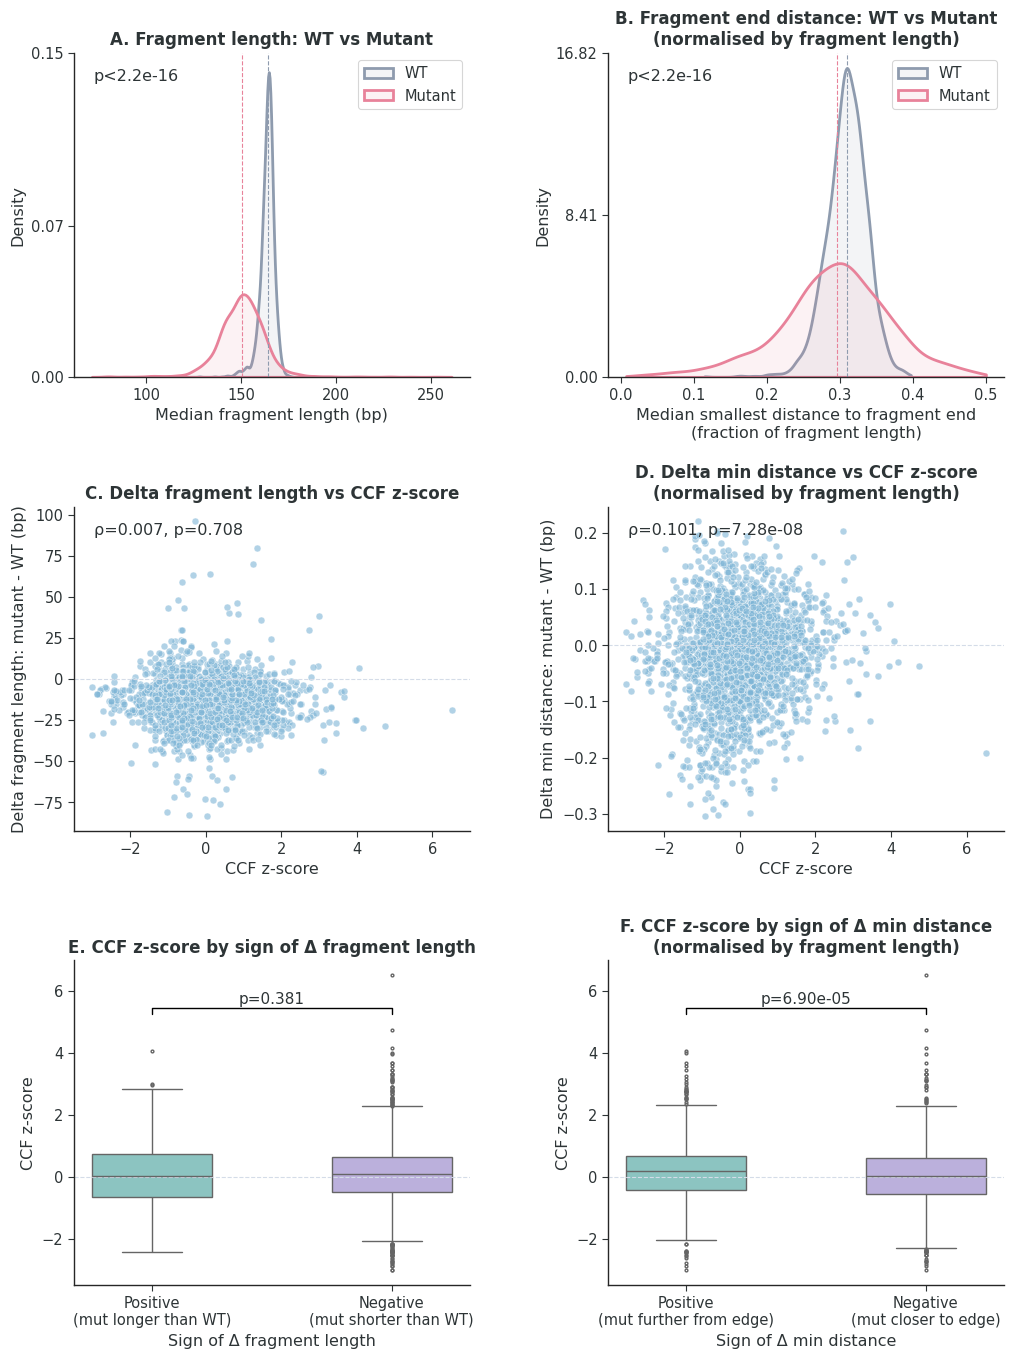

In [52]:
#---------------------------- Figure setup ----------------------------#

fig = plt.figure(figsize=(12, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_e = fig.add_subplot(gs[2, 0])
ax_f = fig.add_subplot(gs[2, 1])

# Set style parameters
sns.set_context("paper", font_scale=1.2)
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['text.color'] = '#2D3436'
plt.rcParams['axes.labelcolor'] = '#2D3436'
plt.rcParams['xtick.color'] = '#2D3436'
plt.rcParams['ytick.color'] = '#2D3436'

# Colour scheme
wt_col = "#8E9BAE"  
mut_col = "#E8829A"     
scatter_col = "#7EB5D6"
high_col = "#82CEC9"    
low_col = "#B8A9E3" 
horiz_line_col = "#D4DCE8"

 #---------------------------- Panel A ----------------------------#

# Wilcoxon signed-rank test (paired per mutation)
stat_a, p_a = wilcoxon(all_mutations_dedup["median_frag_length_wt"].dropna(),
                       all_mutations_dedup["median_frag_length_mut"].dropna())

sns.kdeplot(all_mutations_dedup["median_frag_length_wt"], 
            fill=True, alpha=0.1, color=wt_col, label="WT", ax=ax_a, linewidth=2)
sns.kdeplot(all_mutations_dedup["median_frag_length_mut"], 
            fill=True, alpha=0.1, color=mut_col, label="Mutant", ax=ax_a, linewidth=2)

ax_a.axvline(all_mutations_dedup["median_frag_length_wt"].median(), color=wt_col, linestyle="--", linewidth=0.8)
ax_a.axvline(all_mutations_dedup["median_frag_length_mut"].median(), color=mut_col, linestyle="--", linewidth=0.8)
ax_a.set_xlabel("Median fragment length (bp)")
ax_a.set_ylabel("Density")
y_max_a = ax_a.get_ylim()[1]
ax_a.set_yticks([0, round(y_max_a/2, 2), round(y_max_a, 2)])
ax_a.set_title("A. Fragment length: WT vs Mutant")
ax_a.text(0.05, 0.95, format_p(p_a), transform=ax_a.transAxes, verticalalignment="top")
ax_a.legend()

 #---------------------------- Panel B ----------------------------#

# Wilcoxon signed-rank test (paired per mutation)
stat_b, p_b = wilcoxon(all_mutations_dedup["median_min_distance_normalised_wt"].dropna(),
                       all_mutations_dedup["median_min_distance_normalised_mut"].dropna())

sns.kdeplot(all_mutations_dedup["median_min_distance_normalised_wt"], 
            fill=True, alpha=0.1, color=wt_col, label="WT", ax=ax_b, linewidth=2, cut=0, clip=(0,0.5))
sns.kdeplot(all_mutations_dedup["median_min_distance_normalised_mut"], 
            fill=True, alpha=0.1, color=mut_col, label="Mutant", ax=ax_b, linewidth=2, cut=0, clip=(0,0.5))

ax_b.axvline(all_mutations_dedup["median_min_distance_normalised_wt"].median(), color=wt_col, linestyle="--", linewidth=0.8)
ax_b.axvline(all_mutations_dedup["median_min_distance_normalised_mut"].median(), color=mut_col, linestyle="--", linewidth=0.8)
ax_b.set_xlabel("Median smallest distance to fragment end\n(fraction of fragment length)")
ax_b.set_ylabel("Density")
y_max_b = ax_b.get_ylim()[1]
ax_b.set_yticks([0, round(y_max_b/2, 2), round(y_max_b, 2)])
ax_b.set_title("B. Fragment end distance: WT vs Mutant\n(normalised by fragment length)")
ax_b.text(0.05, 0.95, format_p(p_b), transform=ax_b.transAxes, verticalalignment="top")
ax_b.legend()

 #---------------------------- Panel C ----------------------------#

# Spearman rho
rho_c, p_c = spearmanr(all_mutations_dedup["ccf_z_score"].dropna(),
                        all_mutations_dedup["delta_frag_length"].dropna())

# Scatter plot
ax_c.scatter(all_mutations_dedup["ccf_z_score"], 
             all_mutations_dedup["delta_frag_length"], 
             alpha=0.6, s=25,
             color=scatter_col, 
             edgecolor='white', linewidth=0.5)

ax_c.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_c.set_xlabel("CCF z-score")
ax_c.set_ylabel("Delta fragment length: mutant - WT (bp)")
ax_c.set_title("C. Delta fragment length vs CCF z-score")
ax_c.text(0.05, 0.95, f"ρ={rho_c:.3f}, {format_p(p_c)}", 
          transform=ax_c.transAxes, verticalalignment="top")

 #---------------------------- Panel D ----------------------------#

# Spearman rho
rho_d, p_d = spearmanr(all_mutations_dedup["ccf_z_score"].dropna(),
                        all_mutations_dedup["delta_min_distance_normalised"].dropna())

# Scatter plot
ax_d.scatter(all_mutations_dedup["ccf_z_score"], 
             all_mutations_dedup["delta_min_distance_normalised"], 
             alpha=0.6, s=25,
             color=scatter_col, 
             edgecolor='white', linewidth=0.5)

ax_d.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_d.set_xlabel("CCF z-score")
ax_d.set_ylabel("Delta min distance: mutant - WT (bp)")
ax_d.set_title("D. Delta min distance vs CCF z-score\n(normalised by fragment length)")
ax_d.text(0.05, 0.95, f"ρ={rho_d:.3f}, {format_p(p_d)}", 
          transform=ax_d.transAxes, verticalalignment="top")

#---------------------------- Panel E ----------------------------#

# Compute sign of deltas
all_mutations_dedup["delta_frag_length_sign"] = np.where(
    all_mutations_dedup["delta_frag_length"] > 0, "Positive\n(mut longer than WT)",
    "Negative\n(mut shorter than WT)"
)

# Mann-Whitney for panel E
pos_e = all_mutations_dedup[all_mutations_dedup["delta_frag_length"] > 0]["ccf_z_score"].dropna()
neg_e = all_mutations_dedup[all_mutations_dedup["delta_frag_length"] < 0]["ccf_z_score"].dropna()
_, p_e = mannwhitneyu(pos_e, neg_e, alternative="two-sided")

# Panel E
sns.boxplot(data=all_mutations_dedup, x="delta_frag_length_sign", y="ccf_z_score",
            order=["Positive\n(mut longer than WT)", "Negative\n(mut shorter than WT)"],
            palette={"Positive\n(mut longer than WT)": high_col,
                     "Negative\n(mut shorter than WT)": low_col},
            hue="delta_frag_length_sign", legend=False,
            ax=ax_e, width=0.5, fliersize=2)
ax_e.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_e.set_xlabel("Sign of Δ fragment length")
ax_e.set_ylabel("CCF z-score")
ax_e.set_title("E. CCF z-score by sign of Δ fragment length")

# Bracket for panel E
y_e = ax_e.get_ylim()[1] * 0.75
ax_e.plot([0, 0, 1, 1],
          [y_e, y_e + 0.2, y_e + 0.2, y_e], color="black", linewidth=1)
ax_e.text(0.5, y_e + 0.25, format_p(p_e), ha="center", va="bottom", fontsize=11)


 #---------------------------- Panel F ----------------------------#

# Compute sign of deltas
all_mutations_dedup["delta_min_distance_sign"] = np.where(
    all_mutations_dedup["delta_min_distance_normalised"] > 0, "Positive\n(mut further from edge)", 
    "Negative\n(mut closer to edge)"
)

# Mann-Whitney for panel F
pos_f = all_mutations_dedup[all_mutations_dedup["delta_min_distance_normalised"] > 0]["ccf_z_score"].dropna()
neg_f = all_mutations_dedup[all_mutations_dedup["delta_min_distance_normalised"] < 0]["ccf_z_score"].dropna()
_, p_f = mannwhitneyu(pos_f, neg_f, alternative="greater")

# Panel F
sns.boxplot(data=all_mutations_dedup, x="delta_min_distance_sign", y="ccf_z_score",
            order=["Positive\n(mut further from edge)", "Negative\n(mut closer to edge)"],
            palette={"Positive\n(mut further from edge)": high_col, 
                     "Negative\n(mut closer to edge)": low_col},
            hue="delta_min_distance_sign", legend=False,
            ax=ax_f, width=0.5, fliersize=2)
ax_f.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_f.set_xlabel("Sign of Δ min distance")
ax_f.set_ylabel("CCF z-score")
ax_f.set_title("F. CCF z-score by sign of Δ min distance\n(normalised by fragment length)")

# Bracket for panel F
y_f = ax_f.get_ylim()[1] * 0.75
ax_f.plot([0, 0, 1, 1],
          [y_f, y_f + 0.2, y_f + 0.2, y_f], color="black", linewidth=1)
ax_f.text(0.5, y_f + 0.25, format_p(p_f), ha="center", va="bottom", fontsize=11)


 #---------------------------- Final plot ----------------------------#

for ax in [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f]:
    sns.despine(ax=ax)
    ax.tick_params(axis='both', which='both', length=4, width=0.8, 
                   bottom=True, left=True, color='#2D3436')
    ax.title.set_weight('bold')
    ax.title.set_fontsize(12)

# Save the figure
plt.savefig(os.path.join(PLOT_DIR, "fragmentomics_wt_vs_mut.pdf"), dpi=300, bbox_inches="tight", format="pdf")
plt.savefig(os.path.join(PLOT_DIR, "fragmentomics_wt_vs_mut.svg"), dpi=300, bbox_inches="tight", format="svg")
plt.show()

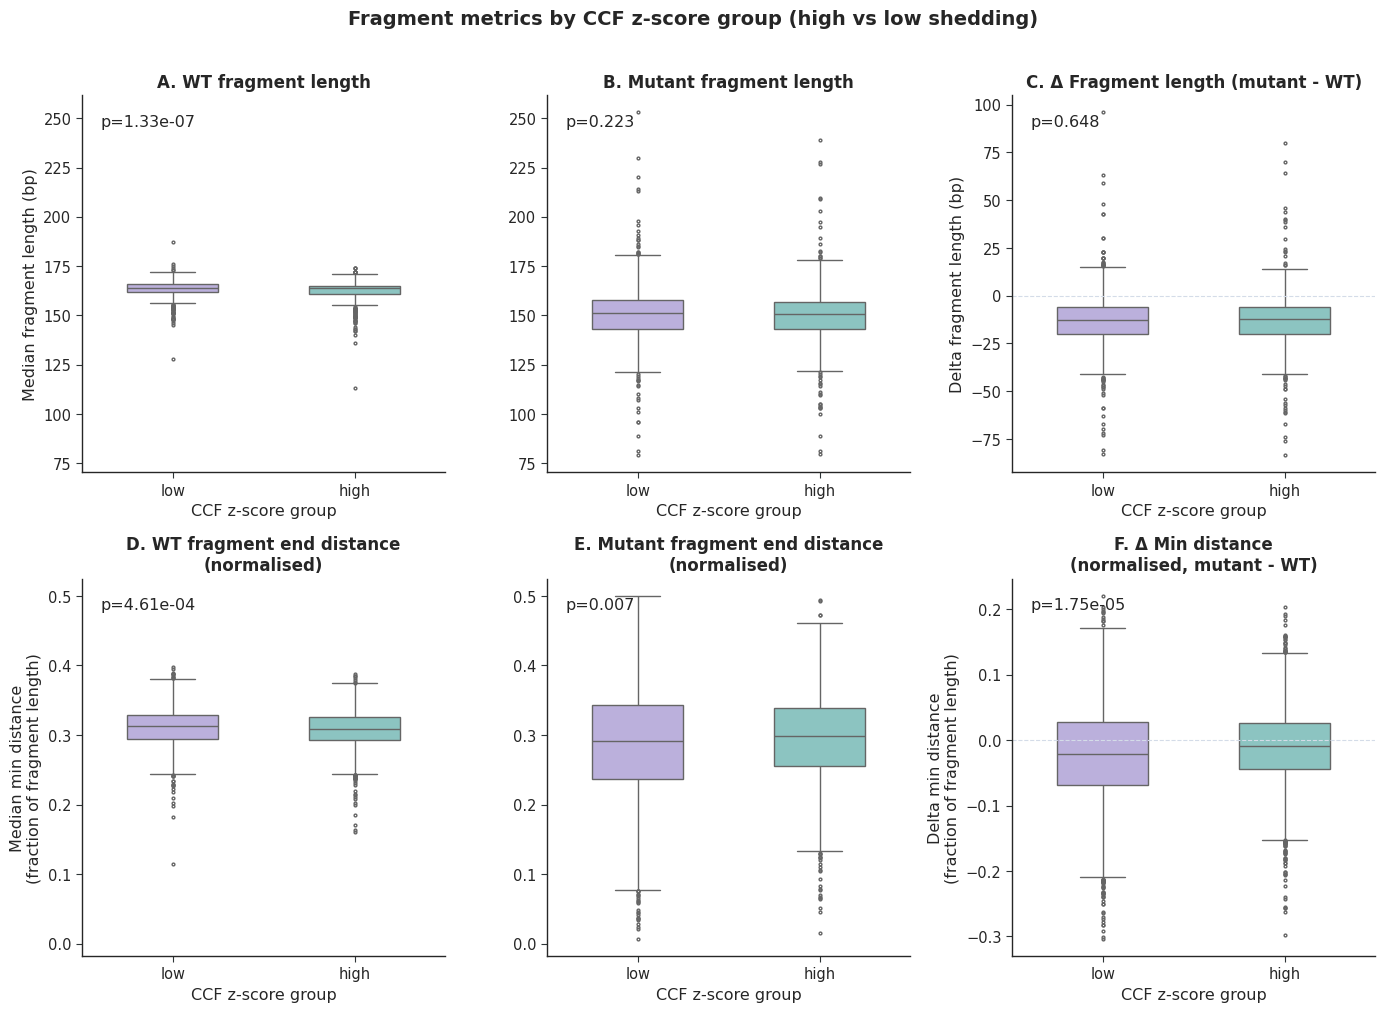

In [54]:
# -----------------------------------------------------------------------------
# Supplementary figure: Fragment length and end distance by CCF z-score group
# -----------------------------------------------------------------------------

fig_supp, axes = plt.subplots(2, 3, figsize=(14, 10))

# Set style parameters
sns.set_context("paper", font_scale=1.2)
sns.set_style("white")

# Mann-Whitney p-values
_, p_wt_fl = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["median_frag_length_wt"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["median_frag_length_wt"].dropna(),
    alternative="two-sided")
_, p_mut_fl = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["median_frag_length_mut"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["median_frag_length_mut"].dropna(),
    alternative="two-sided")
_, p_delta_fl = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["delta_frag_length"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["delta_frag_length"].dropna(),
    alternative="two-sided")
_, p_wt_md = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["median_min_distance_normalised_wt"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["median_min_distance_normalised_wt"].dropna(),
    alternative="two-sided")
_, p_mut_md = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["median_min_distance_normalised_mut"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["median_min_distance_normalised_mut"].dropna(),
    alternative="two-sided")
_, p_delta_md = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["delta_min_distance_normalised"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["delta_min_distance_normalised"].dropna(),
    alternative="two-sided")

# Row 1: Fragment length
for ax, metric, title, p_val, ylabel in zip(
    axes[0],
    ["median_frag_length_wt", "median_frag_length_mut", "delta_frag_length"],
    ["A. WT fragment length", "B. Mutant fragment length", "C. Δ Fragment length (mutant - WT)"],
    [p_wt_fl, p_mut_fl, p_delta_fl],
    ["Median fragment length (bp)", "", "Delta fragment length (bp)"]
):
    sns.boxplot(data=all_mutations_dedup, x="ccf_z_score_group", y=metric,
                order=["low", "high"],
                hue="ccf_z_score_group", hue_order=["low", "high"],
                palette={"low": low_col, "high": high_col},
                legend=False, ax=ax, width=0.5, fliersize=2)
    if "delta" in metric:
        ax.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("CCF z-score group")
    ax.set_ylabel(ylabel)
    ax.text(0.05, 0.95, format_p(p_val), transform=ax.transAxes, verticalalignment="top")

# Share y axis between panels A and B
ymin = min(axes[0][0].get_ylim()[0], axes[0][1].get_ylim()[0])
ymax = max(axes[0][0].get_ylim()[1], axes[0][1].get_ylim()[1])
axes[0][0].set_ylim(ymin, ymax)
axes[0][1].set_ylim(ymin, ymax)

# Row 2: Fragment end distance
for ax, metric, title, p_val, ylabel in zip(
    axes[1],
    ["median_min_distance_normalised_wt", "median_min_distance_normalised_mut", "delta_min_distance_normalised"],
    ["D. WT fragment end distance\n(normalised)", "E. Mutant fragment end distance\n(normalised)", "F. Δ Min distance\n(normalised, mutant - WT)"],
    [p_wt_md, p_mut_md, p_delta_md],
    ["Median min distance\n(fraction of fragment length)", "", "Delta min distance\n(fraction of fragment length)"]
):
    sns.boxplot(data=all_mutations_dedup, x="ccf_z_score_group", y=metric,
                order=["low", "high"],
                hue="ccf_z_score_group", hue_order=["low", "high"],
                palette={"low": low_col, "high": high_col},
                legend=False, ax=ax, width=0.5, fliersize=2)
    if "delta" in metric:
        ax.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("CCF z-score group")
    ax.set_ylabel(ylabel)
    ax.text(0.05, 0.95, format_p(p_val), transform=ax.transAxes, verticalalignment="top")

# Share y axis between panels D and E
ymin = min(axes[1][0].get_ylim()[0], axes[1][1].get_ylim()[0])
ymax = max(axes[1][0].get_ylim()[1], axes[1][1].get_ylim()[1])
axes[1][0].set_ylim(ymin, ymax)
axes[1][1].set_ylim(ymin, ymax)

# Plot
for ax in axes.flatten():
    sns.despine(ax=ax)
    ax.tick_params(axis='both', which='both', length=4, width=0.8,
                   bottom=True, left=True, color='#2D3436')
    ax.title.set_weight('bold')
    ax.title.set_fontsize(12)

plt.suptitle("Fragment metrics by CCF z-score group (high vs low shedding)", 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

plt.savefig(os.path.join(PLOT_DIR, "supplementary_fragmentomics_by_ccf_group.pdf"), 
            dpi=300, bbox_inches="tight", format="pdf")
plt.savefig(os.path.join(PLOT_DIR, "supplementary_fragmentomics_by_ccf_group.svg"), 
            dpi=300, bbox_inches="tight", format="svg")
plt.show()

In [11]:
# Composite score of delta min distance and delta frag length
from scipy.stats import zscore

# Standardise both metrics
all_mutations_dedup["delta_frag_length_z"] = zscore(all_mutations_dedup["delta_frag_length"].dropna())
all_mutations_dedup["delta_min_distance_z"] = zscore(all_mutations_dedup["delta_min_distance_normalised"].dropna())

# Composite score
all_mutations_dedup["composite_score"] = all_mutations_dedup["delta_frag_length_z"] + all_mutations_dedup["delta_min_distance_z"]

# Correlate with CCF z-score
rho_comp, p_comp = spearmanr(
    all_mutations_dedup["ccf_z_score"].dropna(),
    all_mutations_dedup["composite_score"].dropna()
)
print(f"Composite score: Spearman ρ={rho_comp:.3f}, p={p_comp:.3f}")
print(f"Delta frag length alone: ρ={rho_c:.3f}, p={p_c:.3f}")
print(f"Delta min distance alone: ρ={rho_d:.3f}, p={p_d:.3f}")

Composite score: Spearman ρ=0.073, p=0.000
Delta frag length alone: ρ=0.007, p=0.708
Delta min distance alone: ρ=0.101, p=0.000


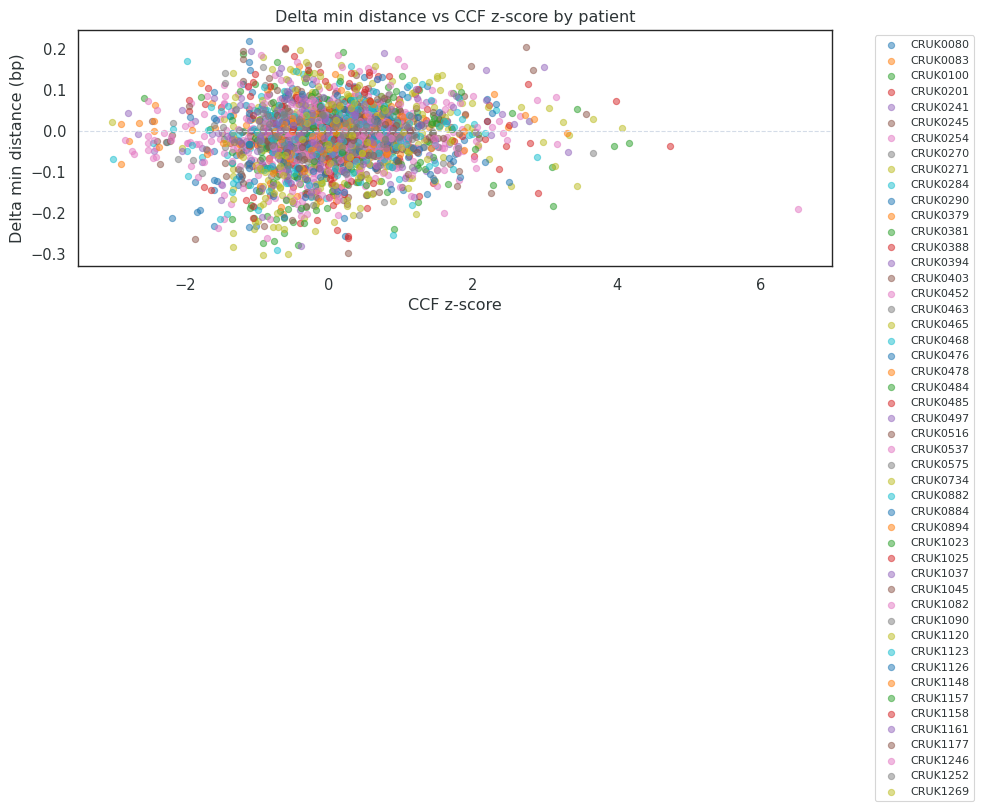

In [12]:
fig_qc, ax_qc = plt.subplots(figsize=(10, 6))

for patient in all_mutations_dedup["cruk_id"].unique():
    subset = all_mutations_dedup[all_mutations_dedup["cruk_id"] == patient]
    ax_qc.scatter(subset["ccf_z_score"], subset["delta_min_distance_normalised"],
                  alpha=0.5, s=20, label=patient)

ax_qc.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_qc.set_xlabel("CCF z-score")
ax_qc.set_ylabel("Delta min distance (bp)")
ax_qc.set_title("Delta min distance vs CCF z-score by patient")
ax_qc.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Fragment lengths

In [13]:
frag_length_long = pd.melt(
    all_mutations_dedup,
    id_vars=["cruk_id", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)

# Clean up fragment_type labels
frag_length_long["fragment_type"] = frag_length_long["fragment_type"].map({
    "median_frag_length_wt": "WT",
    "median_frag_length_mut": "Mutant"
})

print(frag_length_long.shape)
print(frag_length_long["fragment_type"].value_counts())

(5646, 9)
fragment_type
WT        2823
Mutant    2823
Name: count, dtype: int64


In [14]:
frag_length_long

,cruk_id,chrom,pos,ref,alt,ccf_z_score,ccf_z_score_group,fragment_type,median_frag_length
0,CRUK0080,chr1,181732775,C,T,0.118598,high,WT,167.0
1,CRUK0080,chr10,74101108,G,T,-0.481539,low,WT,165.0
2,CRUK0080,chr11,824292,G,T,0.096451,high,WT,162.0
3,CRUK0080,chr11,1256706,G,A,-1.217992,low,WT,167.0
4,CRUK0080,chr11,10803498,T,C,1.029111,high,WT,163.0
...,...,...,...,...,...,...,...,...,...
5641,CRUK1269,chr7,82136696,C,A,-0.773095,low,Mutant,101.0
5642,CRUK1269,chr8,76705845,C,A,0.000264,high,Mutant,129.5
5643,CRUK1269,chr8,113173864,T,A,-1.297344,low,Mutant,150.0
5644,CRUK1269,chr8,141441202,G,T,-0.759383,low,Mutant,129.0


In [15]:
frag_length_long["group"] = frag_length_long["ccf_z_score_group"] + " " + frag_length_long["fragment_type"]
print(frag_length_long["group"].value_counts())

group
high WT        1531
high Mutant    1531
low WT         1292
low Mutant     1292
Name: count, dtype: int64


In [16]:
frag_length_long

,cruk_id,chrom,pos,ref,alt,ccf_z_score,ccf_z_score_group,fragment_type,median_frag_length,group
0,CRUK0080,chr1,181732775,C,T,0.118598,high,WT,167.0,high WT
1,CRUK0080,chr10,74101108,G,T,-0.481539,low,WT,165.0,low WT
2,CRUK0080,chr11,824292,G,T,0.096451,high,WT,162.0,high WT
3,CRUK0080,chr11,1256706,G,A,-1.217992,low,WT,167.0,low WT
4,CRUK0080,chr11,10803498,T,C,1.029111,high,WT,163.0,high WT
...,...,...,...,...,...,...,...,...,...,...
5641,CRUK1269,chr7,82136696,C,A,-0.773095,low,Mutant,101.0,low Mutant
5642,CRUK1269,chr8,76705845,C,A,0.000264,high,Mutant,129.5,high Mutant
5643,CRUK1269,chr8,113173864,T,A,-1.297344,low,Mutant,150.0,low Mutant
5644,CRUK1269,chr8,141441202,G,T,-0.759383,low,Mutant,129.0,low Mutant


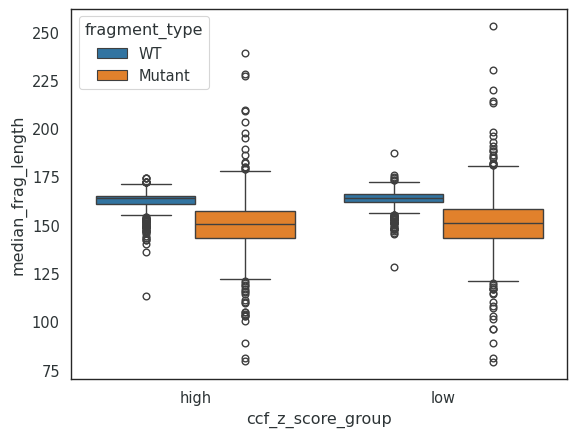

In [17]:
sns.boxplot(
    data=frag_length_long,
    x="ccf_z_score_group",
    y="median_frag_length",
    hue="fragment_type"
)
plt.show()

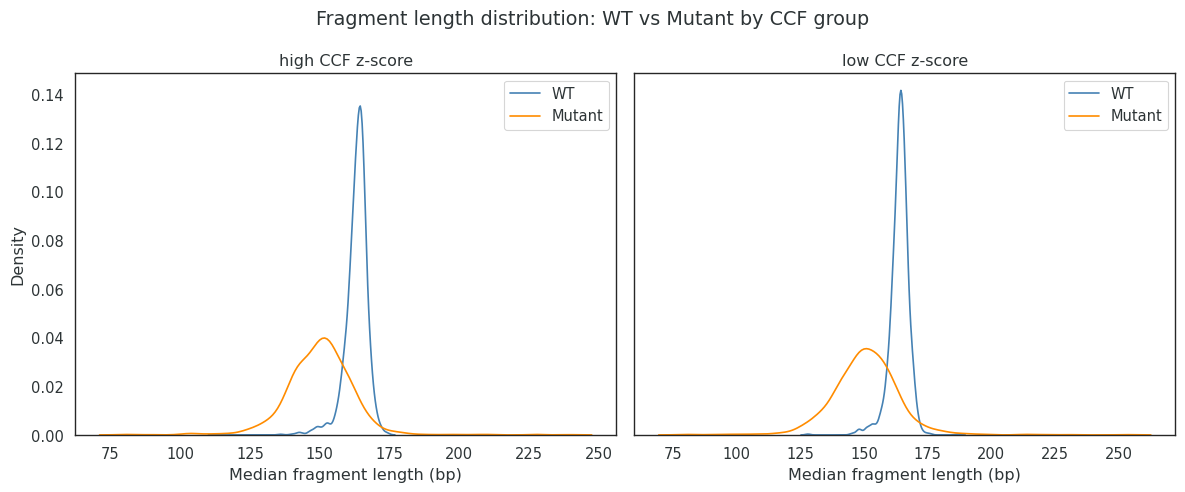

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, group in zip(axes, ["high", "low"]):
    for ftype, color in zip(["WT", "Mutant"], ["steelblue", "darkorange"]):
        subset = frag_length_long[
            (frag_length_long["ccf_z_score_group"] == group) &
            (frag_length_long["fragment_type"] == ftype)
        ]
        sns.kdeplot(subset["median_frag_length"], label=ftype, color=color, ax=ax)
    ax.set_title(f"{group} CCF z-score")
    ax.set_xlabel("Median fragment length (bp)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Fragment length distribution: WT vs Mutant by CCF group")
plt.tight_layout()
plt.show()

In [19]:
# Compute difference between differences in fragment length
all_mutations_dedup["delta_frag_length"] = all_mutations_dedup["median_frag_length_mut"] - all_mutations_dedup["median_frag_length_wt"]

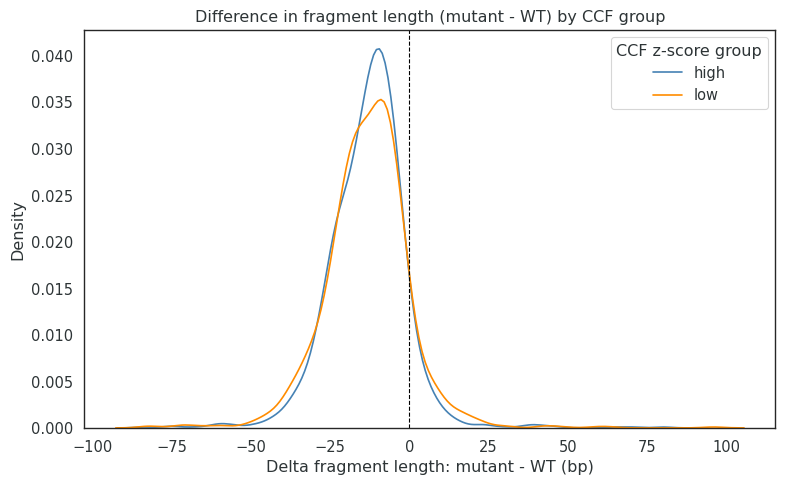

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_frag_length"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta fragment length: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in fragment length (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

In [21]:
# Continuous correlation (Spearman)
spearmanr(all_mutations_dedup["ccf_z_score"].dropna(), all_mutations_dedup["delta_frag_length"].dropna())

SignificanceResult(statistic=0.00705449906148601, pvalue=0.7079150701795257)

## Distances

In [22]:
all_mutations_dedup["delta_min_distance"] = all_mutations_dedup["median_min_distance_mut"] - all_mutations_dedup["median_min_distance_wt"]

In [23]:
spearmanr(all_mutations_dedup["ccf_z_score"].dropna(), all_mutations_dedup["delta_min_distance"].dropna())

SignificanceResult(statistic=0.08218502180735916, pvalue=1.2305097804099456e-05)

In [24]:
print(all_mutations_dedup["delta_min_distance"].describe())
print(all_mutations_dedup["delta_min_distance"].median())

count    2823.000000
mean       -6.448990
std        12.684935
min       -52.000000
25%       -13.500000
50%        -6.000000
75%         1.000000
max        70.000000
Name: delta_min_distance, dtype: float64
-6.0


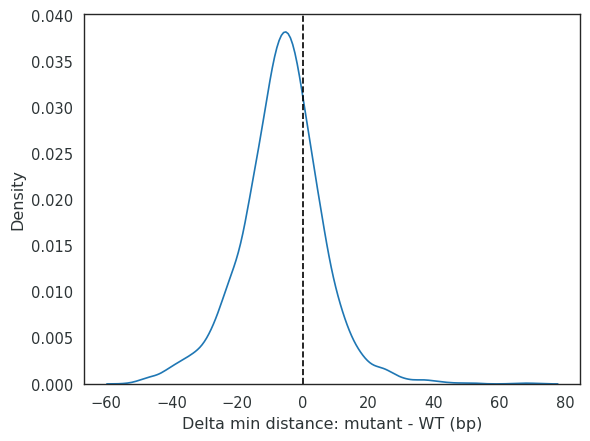

In [25]:
sns.kdeplot(all_mutations_dedup["delta_min_distance"].dropna())
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Delta min distance: mutant - WT (bp)")
plt.show()

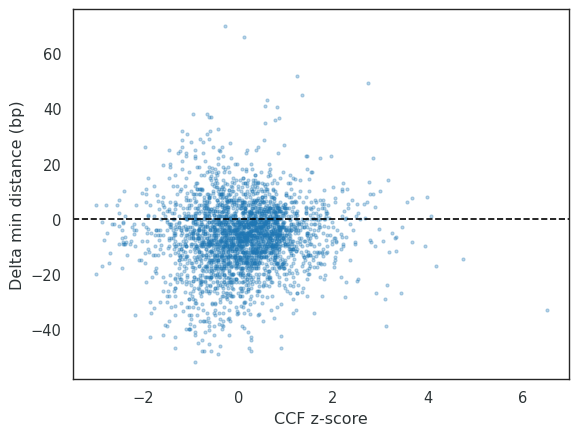

In [26]:
plt.scatter(all_mutations_dedup["ccf_z_score"], all_mutations_dedup["delta_min_distance"], alpha=0.3, s=5)
plt.xlabel("CCF z-score")
plt.ylabel("Delta min distance (bp)")
plt.axhline(0, color="black", linestyle="--")
plt.show()

# Without deduplication (this is not best practice)

In [27]:
# Compute deltas
all_mutations["delta_frag_length"] = all_mutations["median_frag_length_mut"] - all_mutations["median_frag_length_wt"]
all_mutations["delta_min_distance"] = all_mutations["median_min_distance_mut"] - all_mutations["median_min_distance_wt"]

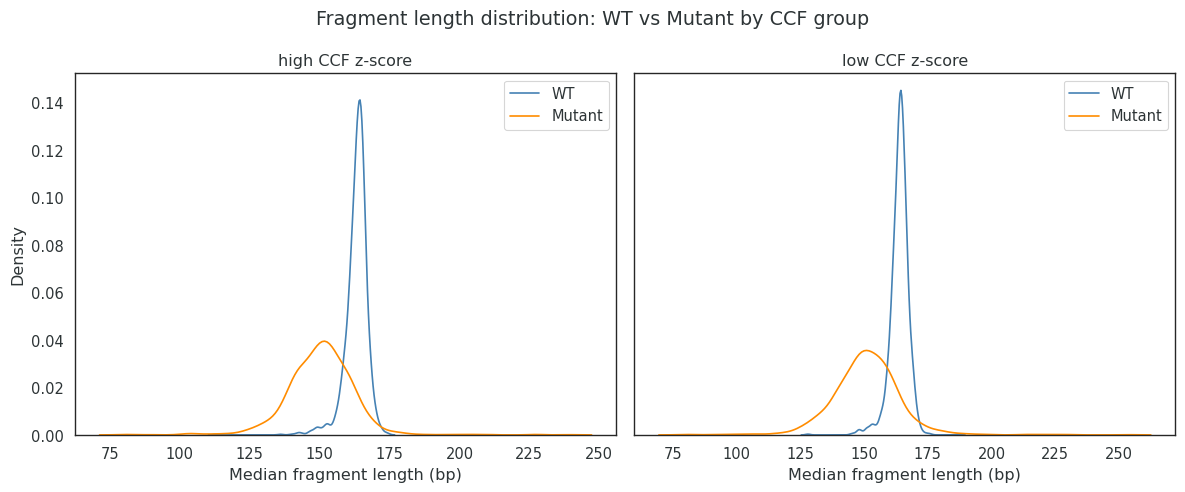

In [28]:
# Fragment length KDE by CCF group
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

frag_length_long = pd.melt(
    all_mutations,
    id_vars=["cruk_id", "sample", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)
frag_length_long["fragment_type"] = frag_length_long["fragment_type"].map({
    "median_frag_length_wt": "WT",
    "median_frag_length_mut": "Mutant"
})

for ax, group in zip(axes, ["high", "low"]):
    for ftype, color in zip(["WT", "Mutant"], ["steelblue", "darkorange"]):
        subset = frag_length_long[
            (frag_length_long["ccf_z_score_group"] == group) &
            (frag_length_long["fragment_type"] == ftype)
        ]
        sns.kdeplot(subset["median_frag_length"], label=ftype, color=color, ax=ax)
    ax.set_title(f"{group} CCF z-score")
    ax.set_xlabel("Median fragment length (bp)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Fragment length distribution: WT vs Mutant by CCF group")
plt.tight_layout()
plt.show()

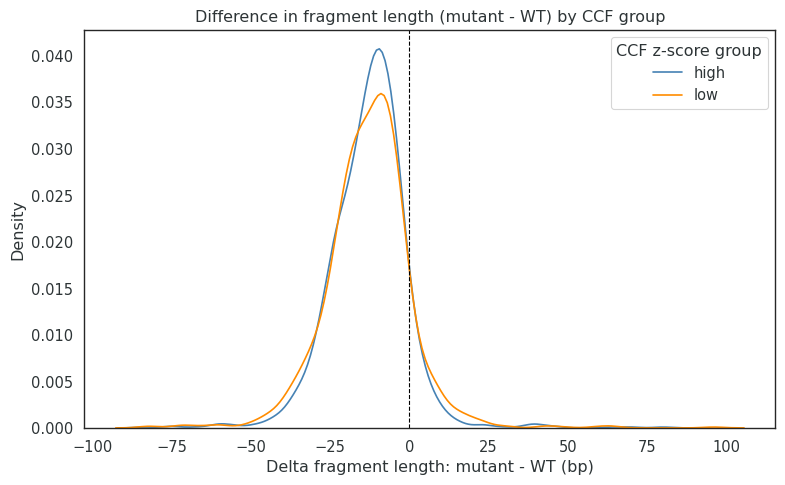

Mann-Whitney U: stat=1131726.0, p=0.6237
Median delta high: -12.00 bp
Median delta low: -12.00 bp
SignificanceResult(statistic=0.005975802939552289, pvalue=0.7434119470930545)


In [29]:
# Delta fragment length KDE and stats
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations[all_mutations["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_frag_length"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta fragment length: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in fragment length (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

high_delta = all_mutations[all_mutations["ccf_z_score_group"] == "high"]["delta_frag_length"].dropna()
low_delta  = all_mutations[all_mutations["ccf_z_score_group"] == "low"]["delta_frag_length"].dropna()
stat, p = mannwhitneyu(high_delta, low_delta, alternative="two-sided")
print(f"Mann-Whitney U: stat={stat:.1f}, p={p:.4f}")
print(f"Median delta high: {high_delta.median():.2f} bp")
print(f"Median delta low: {low_delta.median():.2f} bp")
print(spearmanr(all_mutations["ccf_z_score"].dropna(), all_mutations["delta_frag_length"].dropna()))

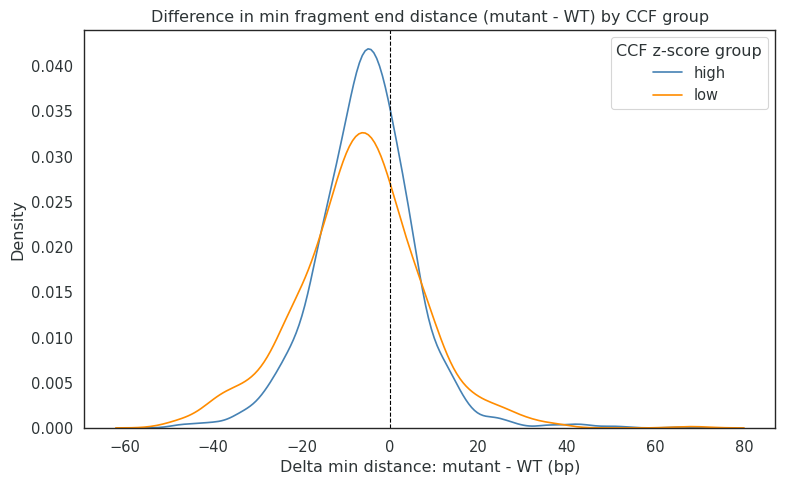

count    3003.000000
mean       -6.242924
std        12.729166
min       -52.000000
25%       -13.500000
50%        -6.000000
75%         1.000000
max        70.000000
Name: delta_min_distance, dtype: float64
SignificanceResult(statistic=0.07503551495783763, pvalue=3.854871773822165e-05)


In [30]:
# Delta min distance KDE and stats
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations[all_mutations["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_min_distance"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta min distance: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in min fragment end distance (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

print(all_mutations["delta_min_distance"].describe())
print(spearmanr(all_mutations["ccf_z_score"].dropna(), all_mutations["delta_min_distance"].dropna()))

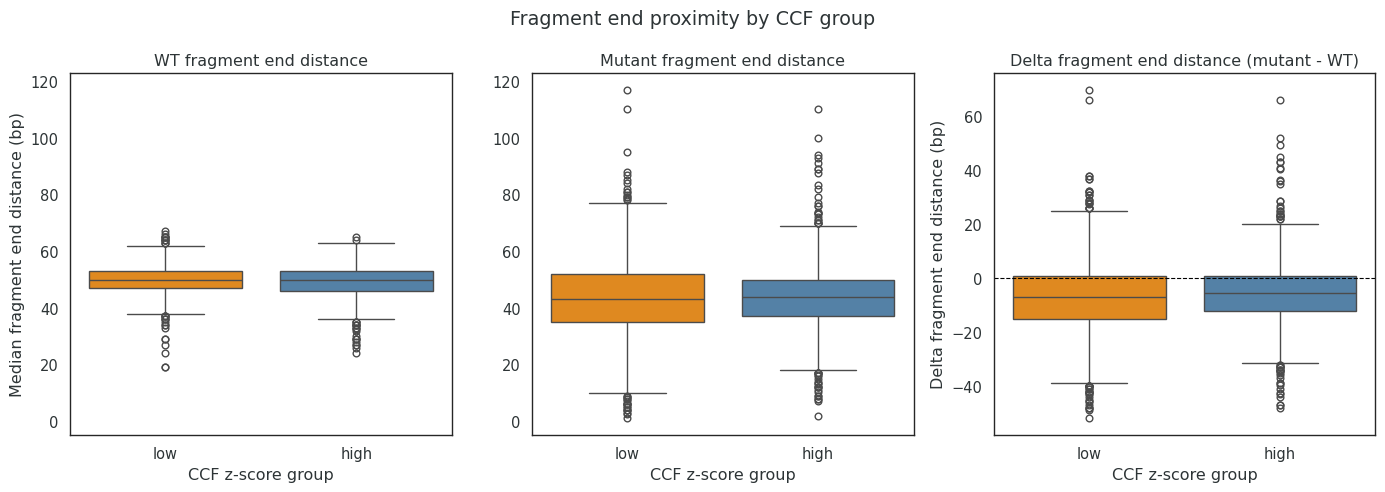

In [31]:
# Fragment end proximity boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="median_min_distance_wt",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[0])
axes[0].set_title("WT fragment end distance")
axes[0].set_xlabel("CCF z-score group")
axes[0].set_ylabel("Median fragment end distance (bp)")

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="median_min_distance_mut",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[1])
axes[1].set_title("Mutant fragment end distance")
axes[1].set_xlabel("CCF z-score group")
axes[1].set_ylabel("")

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="delta_min_distance",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[2])
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Delta fragment end distance (mutant - WT)")
axes[2].set_xlabel("CCF z-score group")
axes[2].set_ylabel("Delta fragment end distance (bp)")

# Share y axis between first two panels
ymin = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(ymin, ymax)
axes[1].set_ylim(ymin, ymax)

plt.suptitle("Fragment end proximity by CCF group")
plt.tight_layout()
plt.show()

/tmp/ipykernel_59641/1290104699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


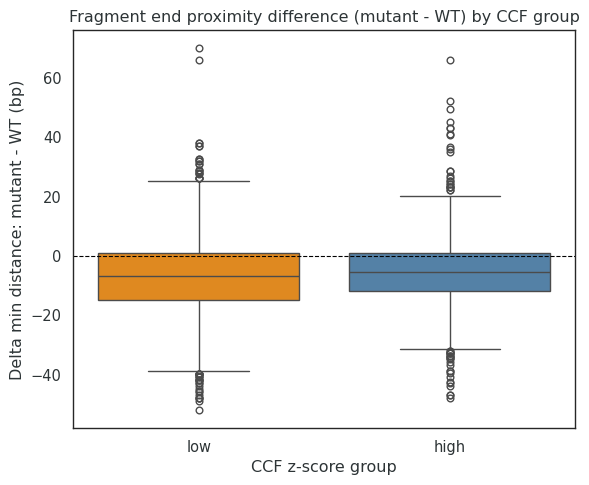

In [32]:
# Box plot showing delta min distance by CCF group
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=all_mutations,
    x="ccf_z_score_group",
    y="delta_min_distance",
    order=["low", "high"],
    palette=["darkorange", "steelblue"],
    ax=ax
)

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("CCF z-score group")
ax.set_ylabel("Delta min distance: mutant - WT (bp)")
ax.set_title("Fragment end proximity difference (mutant - WT) by CCF group")
plt.tight_layout()
plt.show()

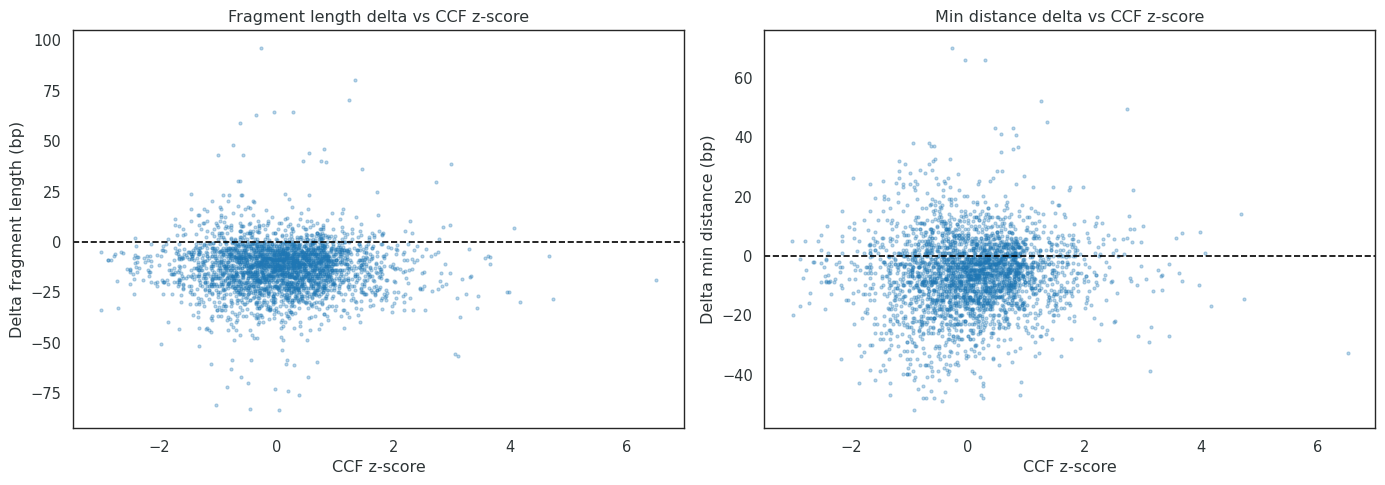

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_mutations["ccf_z_score"], all_mutations["delta_frag_length"], alpha=0.3, s=5)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("CCF z-score")
axes[0].set_ylabel("Delta fragment length (bp)")
axes[0].set_title("Fragment length delta vs CCF z-score")

axes[1].scatter(all_mutations["ccf_z_score"], all_mutations["delta_min_distance"], alpha=0.3, s=5)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("CCF z-score")
axes[1].set_ylabel("Delta min distance (bp)")
axes[1].set_title("Min distance delta vs CCF z-score")

plt.tight_layout()
plt.show()

# Data counts for report

In [34]:
# Fragment counts summary
print("=== Mutant fragment counts ===")
print(all_mutations_dedup["nb_mut"].describe())

print("\n=== WT fragment counts ===")
print(all_mutations_dedup["nb_wt"].describe())

print("\n=== Fragment length summary ===")
print("Median WT fragment length:", all_mutations_dedup["median_frag_length_wt"].median())
print("Median mutant fragment length:", all_mutations_dedup["median_frag_length_mut"].median())
print("Median delta fragment length:", all_mutations_dedup["delta_frag_length"].median())

print("\n=== Min distance summary ===")
print("Median WT min distance:", all_mutations_dedup["median_min_distance_wt"].median())
print("Median mutant min distance:", all_mutations_dedup["median_min_distance_mut"].median())
print("Median delta min distance:", all_mutations_dedup["delta_min_distance"].median())

print("\n=== Sign of delta min distance ===")
print(all_mutations_dedup["delta_min_distance_sign"].value_counts())

print("\n=== Mutations per patient ===")
print(all_mutations_dedup.groupby("cruk_id").size().describe())

print("\n=== CCF z-score group counts ===")
print(all_mutations_dedup["ccf_z_score_group"].value_counts())

=== Mutant fragment counts ===
count    2823.000000
mean       65.337230
std       127.107276
min         1.000000
25%         5.000000
50%        12.000000
75%        68.000000
max      1608.000000
Name: nb_mut, dtype: float64

=== WT fragment counts ===
count    2823.000000
mean     2951.857598
std      1077.919584
min       354.000000
25%      2164.000000
50%      2902.000000
75%      3671.500000
max      9342.000000
Name: nb_wt, dtype: float64

=== Fragment length summary ===
Median WT fragment length: 164.0
Median mutant fragment length: 150.5
Median delta fragment length: -12.0

=== Min distance summary ===
Median WT min distance: 50.0
Median mutant min distance: 43.0
Median delta min distance: -6.0

=== Sign of delta min distance ===
delta_min_distance_sign
Negative\n(mut closer to edge)       1662
Positive\n(mut further from edge)    1161
Name: count, dtype: int64

=== Mutations per patient ===
count     49.000000
mean      57.612245
std       49.755576
min        6.000000
25% 

In [36]:
for group in ["low", "high"]:
    subset = all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == group]
    print(f"\n=== {group.upper()} CCF z-score group (n={len(subset)}) ===")
    print(f"Median min distance mutant normalised: {subset['median_min_distance_normalised_mut'].median():.2f} bp (IQR: {subset['median_min_distance_normalised_mut'].quantile(0.25):.2f}-{subset['median_min_distance_normalised_mut'].quantile(0.75):.2f})")
    print(f"Median min distance WT normalised:     {subset['median_min_distance_normalised_wt'].median():.2f} bp (IQR: {subset['median_min_distance_normalised_wt'].quantile(0.25):.2f}-{subset['median_min_distance_normalised_wt'].quantile(0.75):.2f})")
    print(f"Delta min distance normalised:         {subset['delta_min_distance_normalised'].median():.2f} bp (IQR: {subset['delta_min_distance_normalised'].quantile(0.25):.2f}-{subset['delta_min_distance_normalised'].quantile(0.75):.2f})")


=== LOW CCF z-score group (n=1292) ===
Median min distance mutant normalised: 0.29 bp (IQR: 0.24-0.34)
Median min distance WT normalised:     0.31 bp (IQR: 0.29-0.33)
Delta min distance normalised:         -0.02 bp (IQR: -0.07-0.03)

=== HIGH CCF z-score group (n=1531) ===
Median min distance mutant normalised: 0.30 bp (IQR: 0.26-0.34)
Median min distance WT normalised:     0.31 bp (IQR: 0.29-0.33)
Delta min distance normalised:         -0.01 bp (IQR: -0.04-0.03)


In [37]:
print(f"Median WT min distance normalised: {all_mutations_dedup['median_min_distance_normalised_wt'].median():.2f} bp")
print(f"Median mutant min distance normalised: {all_mutations_dedup['median_min_distance_normalised_mut'].median():.2f} bp")
print(f"Median delta min distance normalised: {all_mutations_dedup['delta_min_distance_normalised'].median():.2f} bp")

Median WT min distance normalised: 0.31 bp
Median mutant min distance normalised: 0.30 bp
Median delta min distance normalised: -0.01 bp


In [38]:
print(f"Median WT fragment length: {all_mutations_dedup['median_frag_length_wt'].median():.2f} bp")
print(f"Median mutant fragment length: {all_mutations_dedup['median_frag_length_mut'].median():.2f} bp")
print(f"Median delta fragment length: {all_mutations_dedup['delta_frag_length'].median():.2f} bp")

Median WT fragment length: 164.00 bp
Median mutant fragment length: 150.50 bp
Median delta fragment length: -12.00 bp


In [55]:
from scipy import stats

pos_group = all_mutations_dedup[all_mutations_dedup["delta_min_distance_normalised"] > 0]["ccf_z_score"].dropna()
neg_group = all_mutations_dedup[all_mutations_dedup["delta_min_distance_normalised"] < 0]["ccf_z_score"].dropna()

# Cohen's d
diff = pos_group.mean() - neg_group.mean()
pooled_std = np.sqrt((pos_group.std()**2 + neg_group.std()**2) / 2)
cohens_d = diff / pooled_std

print(f"Cohen's d: {cohens_d:.3f}")
print(f"Mean CCF z-score positive delta: {pos_group.mean():.3f}")
print(f"Mean CCF z-score negative delta: {neg_group.mean():.3f}")
print(f"Difference in means: {diff:.3f}")

Cohen's d: 0.138
Mean CCF z-score positive delta: 0.163
Mean CCF z-score negative delta: 0.032
Difference in means: 0.131
